# Paths for  Heston - Euler scheme vs Almost exact simulations

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import enum 

In [17]:
# This uses Euler scheme to simulate the Heston model for X = log(S)
def GeneratePathsHestonEuler(NoOfSteps,T,r,S_0,kappa,gamma,rho,vbar,v0, NoOfPaths = 1):    
    Z1 = np.random.normal(0.0,1.0,[NoOfPaths,NoOfSteps])
    Z2 = np.random.normal(0.0,1.0,[NoOfPaths,NoOfSteps])
    
    W1 = np.zeros([NoOfPaths, NoOfSteps+1])
    W2 = np.zeros([NoOfPaths, NoOfSteps+1])
    
    V = np.zeros([NoOfPaths, NoOfSteps+1])
    X = np.zeros([NoOfPaths, NoOfSteps+1])
    
    V[:,0] = v0
    X[:,0] = np.log(S_0)
    
    time = np.zeros([NoOfSteps+1])
        
    dt = T / float(NoOfSteps)
    
    for i in range(0,NoOfSteps):

        # Making sure that samples from a normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z1[:,i] = (Z1[:,i] - np.mean(Z1[:,i])) / np.std(Z1[:,i])
            Z2[:,i] = (Z2[:,i] - np.mean(Z2[:,i])) / np.std(Z2[:,i])
            
        Z2[:,i] = rho * Z1[:,i] + np.sqrt(1.0-rho**2)*Z2[:,i]
        
        W1[:,i+1] = W1[:,i] + np.power(dt, 0.5)*Z1[:,i]
        W2[:,i+1] = W2[:,i] + np.power(dt, 0.5)*Z2[:,i]
        
        # Truncated boundary condition
        V[:,i+1] = V[:,i] + kappa*(vbar - V[:,i]) * dt + gamma* np.sqrt(V[:,i]) * (W1[:,i+1]-W1[:,i])
        V[:,i+1] = np.maximum(V[:,i+1],0.0)
        
        X[:,i+1] = X[:,i] + (r - 0.5*V[:,i])*dt + np.sqrt(V[:,i])*(W2[:,i+1]-W2[:,i])
        
        time[i+1] = time[i] +dt
        
    # Compute exponent

    S = np.exp(X)
    paths = {"time":time,"S":S}
    
    return paths

## Heston Model - Euler Scheme

The Heston model couples asset price $S_t$ with stochastic volatility $V_t$:

$$\begin{cases}
dS_t = \mu S_t dt + \sqrt{V_t}S_t dW_x(t) \\
dV_t = \kappa(\bar{v} - V_t)dt + \gamma\sqrt{V_t}dW_v(t)
\end{cases}$$

where $dW_x \cdot dW_v = \rho dt$ (correlation $\rho$).

We use **Cholesky decomposition** to generate correlated Brownian motions and the **truncated Euler scheme** for the variance process to ensure positivity.

In [18]:
# This applies the AE scheme by sampling from a chi-squared distribution
def CIR_Sample(NoOfPaths,kappa,gamma,vbar,s,t,v_s):
    delta = 4.0 *kappa*vbar/gamma/gamma
    c = 1.0/(4.0*kappa)*gamma*gamma*(1.0-np.exp(-kappa*(t-s)))
    kappaBar = 4.0*kappa*v_s*np.exp(-kappa*(t-s))/(gamma*gamma*(1.0-np.exp(-kappa*(t-s))))
    sample = c* np.random.noncentral_chisquare(delta,kappaBar,NoOfPaths)
    
    return  sample

def GeneratePathsHestonAES(NoOfSteps,T,r,S_0,kappa,gamma,rho,vbar,v0, NoOfPaths = 1):    
    
    Z1 = np.random.normal(0.0,1.0,[NoOfPaths,NoOfSteps])
    W1 = np.zeros([NoOfPaths, NoOfSteps+1])
    
    V = np.zeros([NoOfPaths, NoOfSteps+1])
    X = np.zeros([NoOfPaths, NoOfSteps+1])
    
    V[:,0]=v0
    X[:,0]=np.log(S_0)
    
    time = np.zeros([NoOfSteps+1])
        
    dt = T / float(NoOfSteps)
    
    for i in range(0,NoOfSteps):

        # making sure that samples from a normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z1[:,i] = (Z1[:,i] - np.mean(Z1[:,i])) / np.std(Z1[:,i])
            
        W1[:,i+1] = W1[:,i] + np.power(dt, 0.5)*Z1[:,i]
        
        # Exact samples for the variance process
        V[:,i+1] = CIR_Sample(NoOfPaths,kappa,gamma,vbar,0,dt,V[:,i])
        
        # Coefficients for the Almost Exact Scheme (Broadie-Kaya style)
        # From: X_{i+1} = X_i + (r - ρκv̄/γ)Δt + [(ρκ/γ - 1/2)Δt - ρ/γ]V_i + (ρ/γ)V_{i+1} + √((1-ρ²)V_i)ΔW
        k0 = (r - rho/gamma*kappa*vbar)*dt  # constant term
        k1 = (rho*kappa/gamma - 0.5)*dt - rho/gamma  # coefficient for V_i
        k2 = rho/gamma                       # coefficient for V_{i+1}
        
        X[:,i+1] = X[:,i] + k0 + k1*V[:,i] + k2*V[:,i+1] + np.sqrt((1.0-rho**2)*V[:,i])*(W1[:,i+1]-W1[:,i])
        
        time[i+1] = time[i] +dt
        
    # Compute exponent
    S = np.exp(X)
    paths = {"time":time,"S":S}
    
    return paths

## Heston Model - Almost Exact Simulation (AES)

The **AES scheme** improves upon Euler by:

1. **Exact simulation** of $V_{i+1}$ using the non-central chi-squared distribution: $V_{i+1} | V_i \sim \bar{c}(t_{i+1},t_i) \chi^2(\delta, \bar{\kappa}(t_{i+1},t_i))$

2. **Semi-analytical update** for $X_t = \log(S_t)$ using the integrated form:
   $$X_{i+1} = X_i + (r - \frac{\rho\kappa\bar{v}}{\gamma})\Delta t + \left[(\frac{\rho\kappa}{\gamma} - \frac{1}{2})\Delta t - \frac{\rho}{\gamma}\right]V_i + \frac{\rho}{\gamma}V_{i+1} + \sqrt{(1-\rho^2)V_i}\Delta W_x$$

This scheme is more accurate and maintains positivity of the variance without truncation.

In [19]:
# Parameters
N = 10
m = 500

# Heston model parameters
gamma = 1.0
kappa = 0.5
vbar  = 0.04
rho   = -0.9
v0    = 0.04
T     = 1.0
S_0   = 100.0
mu    = 0.1

In [20]:
# Euler simulation
pathsEULER = GeneratePathsHestonEuler(m,T,mu,S_0,kappa,gamma,rho,vbar,v0, N)
S_Euler = pathsEULER["S"]
    
# Almost exact simulation
pathsAES = GeneratePathsHestonAES(m,T,mu,S_0,kappa,gamma,rho,vbar,v0, N)
S_AES = pathsAES["S"]

timeGrid = pathsAES["time"]

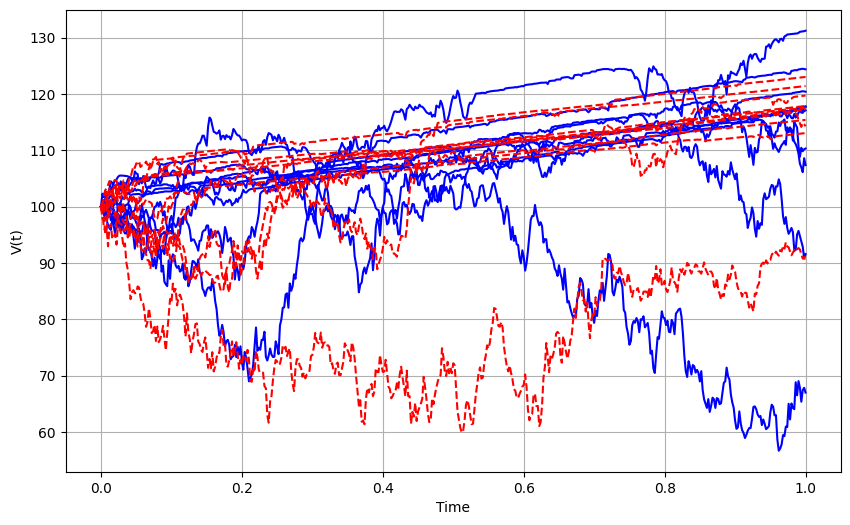

In [21]:
# Initialize the figure with a specific size (optional for better visualization)
plt.figure(figsize=(10, 6))

# Plot the Euler simulation data
plt.plot(timeGrid, np.transpose(S_Euler), 'b', label='Euler Simulation')

# Plot the Almost Exact Simulation data
plt.plot(timeGrid, np.transpose(S_AES), '--r', label='Almost Exact Simulation')

# Add grid for easier data visualization
plt.grid(True)

# Set x and y axis labels with more descriptive units if applicable
plt.xlabel("Time")
plt.ylabel("V(t)")

# Display legend with location for clarity
#plt.legend(loc='best')

# Show plot
plt.show()

The current parameters **violate** the Feller condition: $2\kappa\bar{v} \geq \gamma^2$

With $\gamma=1.0$, $\kappa=0.5$, $\bar{v}=0.04$: $2 \times 0.5 \times 0.04 = 0.04 < 1.0 = \gamma^2$

When violated, the variance process frequently hits zero, which:
- Kills the diffusion term $\sqrt{V_i}$
- Causes paths to "freeze" (constant line behavior)
- Makes the simulation unstable

## Simulation with Feller-Satisfying Parameters

Below we use parameters that satisfy the Feller condition $2\kappa\bar{v} \geq \gamma^2$:
- $\gamma = 0.3$ (vol-of-vol)
- $\kappa = 2.0$ (faster mean reversion)  
- $\bar{v} = 0.04$ (long-term variance ≈ 20% vol)

Check: $2 \times 2.0 \times 0.04 = 0.16 > 0.09 = 0.3^2$ ✓

In [22]:
# Stable parameters satisfying Feller condition: 2*kappa*vbar >= gamma^2
N_stable = 10
m_stable = 500

gamma_stable = 0.3    # vol-of-vol (reduced from 1.0)
kappa_stable = 2.0    # mean reversion speed (increased from 0.5)
vbar_stable  = 0.04   # long-term variance
rho_stable   = -0.7   # correlation
v0_stable    = 0.04   # initial variance
T_stable     = 1.0
S_0_stable   = 100.0
mu_stable    = 0.1

# Verify Feller condition
feller_lhs = 2 * kappa_stable * vbar_stable
feller_rhs = gamma_stable**2
print(f"Feller condition: 2κv̄ = {feller_lhs:.4f} >= γ² = {feller_rhs:.4f} → {feller_lhs >= feller_rhs}")

Feller condition: 2κv̄ = 0.1600 >= γ² = 0.0900 → True


In [23]:
# Run simulations with stable parameters
pathsEULER_stable = GeneratePathsHestonEuler(m_stable, T_stable, mu_stable, S_0_stable, 
                                              kappa_stable, gamma_stable, rho_stable, 
                                              vbar_stable, v0_stable, N_stable)
S_Euler_stable = pathsEULER_stable["S"]

pathsAES_stable = GeneratePathsHestonAES(m_stable, T_stable, mu_stable, S_0_stable, 
                                          kappa_stable, gamma_stable, rho_stable, 
                                          vbar_stable, v0_stable, N_stable)
S_AES_stable = pathsAES_stable["S"]

timeGrid_stable = pathsAES_stable["time"]

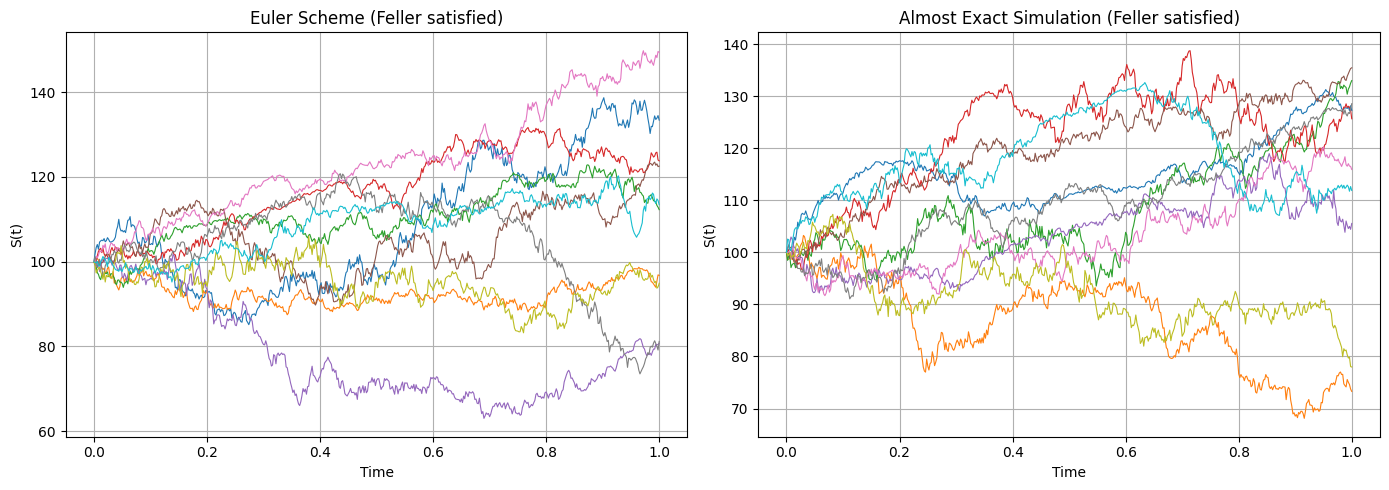

In [24]:
# Plot comparison with stable parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Euler scheme
axes[0].plot(timeGrid_stable, np.transpose(S_Euler_stable), linewidth=0.8)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("S(t)")
axes[0].set_title("Euler Scheme (Feller satisfied)")
axes[0].grid(True)

# AES scheme
axes[1].plot(timeGrid_stable, np.transpose(S_AES_stable), linewidth=0.8)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("S(t)")
axes[1].set_title("Almost Exact Simulation (Feller satisfied)")
axes[1].grid(True)

plt.tight_layout()
plt.show()